# Avance 2 – Ingeniería de Características  
## Proyecto Integrador – Equipo 22

Integrantes:
*   María Virginia Mendizábal Miranda - A01796588
*   Gianmel Joannelly Hernandez Tosta - A01795919
*   Sofía Ordaz López - A01173717

**Proyecto:** Análisis de biomarcadores lipidómicos y metabolómicos mediante modelos de *machine learning* interpretativo para clasificación multiclase de cáncer colorrectal.

**Variable objetivo:** `group` con tres clases clínicas: `CTRL`, `AA` y `CRC`.

**Continuidad con Avance 1:** Esta libreta parte del mismo conjunto de datos, la misma reconstrucción de encabezados, la misma depuración inicial y las observaciones del EDA. El objetivo de este avance es convertir el dataset depurado en una matriz de características útil para modelos supervisados.

## Objetivos del Avance 2

De acuerdo con la actividad de **Ingeniería de Características**, esta libreta cubre:

1. **Construcción de características**
   - Crear nuevas variables significativas basadas en conocimiento del dominio lipidómico/metabolómico.
   - Codificar variables categóricas mediante técnicas adecuadas.
   - Justificar cada decisión de procesamiento.

2. **Normalización y transformación**
   - Escalar variables para que tengan impacto equitativo en los modelos.
   - Aplicar transformaciones para reducir asimetría y mejorar la distribución de variables.
   - Justificar cada técnica empleada.

3. **Selección y extracción de características**
   - Aplicar métodos de filtrado y extracción para reducir complejidad.
   - Facilitar interpretación y acelerar etapas posteriores de entrenamiento.

4. **Conclusión CRISP-ML(Q)**
   - Cerrar la fase de preparación de datos en el contexto de la metodología CRISP-ML(Q).

## 1. Configuración inicial

In [28]:
import os
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import skew, shapiro, boxcox

from sklearn.preprocessing import (
    StandardScaler,
    PowerTransformer,
    KBinsDiscretizer,
    LabelEncoder
)

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif,
    f_classif,
    chi2
)

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 120)

RANDOM_STATE = 42

print('Setup listo.')

Setup listo.


## 2. Carga del dataset y reconstrucción de encabezados

El archivo original contiene filas de metadatos que describen familias, subfamilias y nombres de metabolitos. Para mantener continuidad con el Avance 1, se reconstruyen los encabezados de forma controlada y se conserva una tabla de metadatos de variables.

In [29]:
# ============================================================
# 1. Montar Google Drive y definir ruta del dataset
# ============================================================
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

DATA_PATH = '/content/drive/MyDrive/Proyecto Integrador/'
file_path = DATA_PATH + 'BASE DE DATOS CRC PROYECT LABELED(Data Mat).csv'

print('Ruta del archivo:', file_path)

Mounted at /content/drive
Ruta del archivo: /content/drive/MyDrive/Proyecto Integrador/BASE DE DATOS CRC PROYECT LABELED(Data Mat).csv


In [30]:
raw = pd.read_csv(file_path, encoding='latin1', header=None)

metadata_rows = raw.iloc[0:4, :].copy()
data = raw.iloc[4:, :].copy().reset_index(drop=True)

families = metadata_rows.iloc[0, :].ffill()
subfamilies = metadata_rows.iloc[1, :]
metabolite_names = metadata_rows.iloc[2, :]
probable_ids = metadata_rows.iloc[3, :]

# Unificar etiqueta con typo observada en el Avance 1
families = families.astype('object').replace({
    'GLYCEROPHOSPHOLIPID': 'GLYCEROPHOSPHOLIPIDS'
})

base_names = {
    0: 'sample',
    1: 'sample_id',
    2: 'group',
    3: 'gender',
    4: 'fob',
    5: 'age',
    6: 'fit_ug_g',
    7: 'z_age',
    8: 'z_fob',
    9: 'age_standardized',
    10: 'fit_standardized'
}

new_cols = []
seen = {}

for i in range(raw.shape[1]):
    if i in base_names:
        col = base_names[i]
    else:
        name = metabolite_names.iloc[i]
        if pd.isna(name) or str(name).strip().lower() == 'nan':
            name = subfamilies.iloc[i]
        if pd.isna(name) or str(name).strip().lower() == 'nan':
            name = f'feature_{i}'
        col = re.sub(r'\s+', ' ', str(name).strip())
        if col in seen:
            seen[col] += 1
            col = f'{col}__dup{seen[col]}'
        else:
            seen[col] = 0
    new_cols.append(col)

data.columns = new_cols

feature_metadata = []
for i, col in enumerate(new_cols):
    if i >= 11:
        feature_metadata.append({
            'column': col,
            'family': str(families.iloc[i]).strip() if pd.notna(families.iloc[i]) else 'Unknown',
            'subfamily': str(subfamilies.iloc[i]).strip() if pd.notna(subfamilies.iloc[i]) else 'Unknown',
            'notation': str(metabolite_names.iloc[i]).strip() if pd.notna(metabolite_names.iloc[i]) else col,
            'probable_id': str(probable_ids.iloc[i]).strip() if pd.notna(probable_ids.iloc[i]) else ''
        })

feature_metadata = pd.DataFrame(feature_metadata)

print(f'Dimensiones del archivo reconstruido: {data.shape}')
print(f'Variables lipidómicas/metabolómicas catalogadas: {len(feature_metadata)}')
display(feature_metadata.head())

Dimensiones del archivo reconstruido: (211, 138)
Variables lipidómicas/metabolómicas catalogadas: 127


,column,family,subfamily,notation,probable_id
0,Cer(d18:1/16:0),SPHINGOLIPIDS,Ceramides,Cer(d18:1/16:0),
1,Cer(d18:1/20:0),SPHINGOLIPIDS,Ceramides,Cer(d18:1/20:0),
2,Cer(d18:1/22:0),SPHINGOLIPIDS,Ceramides,Cer(d18:1/22:0),
3,Cer(d18:1/23:0),SPHINGOLIPIDS,Ceramides,Cer(d18:1/23:0),
4,Cer(d18:1/24:0),SPHINGOLIPIDS,Ceramides,Cer(d18:1/24:0),


## 3. Limpieza inicial y separación de variables

### Justificación

Se eliminan identificadores y versiones estandarizadas heredadas del archivo original para evitar ruido y duplicidad. Las versiones estandarizadas (`z_age`, `z_fob`, `age_standardized`, `fit_standardized`) no deben coexistir con las variables originales porque podrían introducir redundancia y afectar indebidamente los análisis posteriores.

El escalamiento se realizará más adelante dentro de esta libreta, de forma explícita y documentada.

In [31]:
# Normalizar variables categóricas
for col in ['group', 'gender', 'fob']:
    if col in data.columns:
        data[col] = data[col].astype(str).str.strip()
        data[col] = data[col].replace({'nan': np.nan, '': np.nan})

# Eliminar identificadores y variables redundantes/ya estandarizadas
columns_to_drop = [
    'sample_id',
    'z_age',
    'z_fob',
    'age_standardized',
    'fit_standardized'
]

data = data.drop(columns=[c for c in columns_to_drop if c in data.columns])

# Convertir variables numéricas
id_and_label_cols = ['sample', 'group', 'gender', 'fob']
for col in data.columns:
    if col not in id_and_label_cols:
        data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna(subset=['group']).reset_index(drop=True)

target_col = 'group'
clinical_numeric_cols = [c for c in ['age', 'fit_ug_g'] if c in data.columns]
categorical_cols = [c for c in ['gender', 'fob'] if c in data.columns]
lipid_cols = [c for c in feature_metadata['column'].tolist() if c in data.columns]

print('Dimensiones tras limpieza inicial:', data.shape)
print('Variables clínicas numéricas:', clinical_numeric_cols)
print('Variables categóricas:', categorical_cols)
print('Variables lipídicas/metabolómicas:', len(lipid_cols))
print('\nDistribución del target:')
display(data[target_col].value_counts().to_frame('n'))

Dimensiones tras limpieza inicial: (211, 133)
Variables clínicas numéricas: ['age', 'fit_ug_g']
Variables categóricas: ['gender', 'fob']
Variables lipídicas/metabolómicas: 127

Distribución del target:


,n
group,
CTRL,78
CRC,75
AA,58


## 4. Diccionario de variables por familia

### Justificación

La profesora solicitó incluir un diccionario de variables al menos por grupo/familia. Esta tabla permite documentar qué variables corresponden a cada familia lipidómica/metabolómica y facilita la interpretación de las nuevas características construidas.

In [32]:
variable_dictionary = (
    feature_metadata[feature_metadata['column'].isin(lipid_cols)]
    .groupby(['family', 'subfamily'])
    .agg(
        n_variables=('column', 'count'),
        examples=('column', lambda x: ', '.join(list(x)[:5]))
    )
    .reset_index()
    .sort_values(['family', 'subfamily'])
)

display(variable_dictionary)

,family,subfamily,n_variables,examples
0,GLYCEROLIPIDS,Diacylglycerols,8,"DG(32:1), DG(34:0), DG(34:1), DG(34:2), DG(36:2)"
1,GLYCEROLIPIDS,Monoacylglycerols,1,MG(18:0/0:0/0:0)
2,GLYCEROLIPIDS,Triacylglycerols,51,"TG(51:0), TG(42:0), TG(46:1), TG(46:2), TG(46:3)"
3,GLYCEROPHOSPHOLIPIDS,"1-ether, 2-acylglycerophosphocholine",8,"PC(O-16:0/16:0), PC(O-34:1), PC(O-16:0/18:2), ..."
4,GLYCEROPHOSPHOLIPIDS,"1-ether, 2-acylglycerophosphoethanolamine",4,"PE(O-16:0/18:1), PE(P-16:0/18:2), PE(P-18:0/18..."
5,GLYCEROPHOSPHOLIPIDS,Diacylglycerophosphocholine,17,"PC(32:0), PC(32:1), PC(34:0), PC(34:1), PC(34:2)"
6,GLYCEROPHOSPHOLIPIDS,Diacylglycerophosphoethanolamine,6,"PE(34:1), PE(34:2), PE(36:3), PE(36:4), PE(36:..."
7,SPHINGOLIPIDS,Ceramides,7,"Cer(d18:1/16:0), Cer(d18:1/20:0), Cer(d18:1/22..."
8,SPHINGOLIPIDS,Monohexosylceramides,2,"GlcCer(d18:1/22:0), GlcCer(d18:1/24:0)"
9,SPHINGOLIPIDS,Sphingomyelin,14,"SM(d18:0/16:0), SM(d18:0/18:0), SM(d18:0/22:0)..."


## 5. Preparación base para ingeniería de características

### 5.1 Filtrado por missingness

Se eliminan lípidos/metabolitos con más de 40% de valores faltantes. Esta decisión proviene del Avance 1 y busca evitar que variables con demasiada ausencia introduzcan inestabilidad en la construcción de características y selección posterior.

In [33]:
missing_threshold = 0.40

lipids_to_drop = [
    c for c in lipid_cols
    if data[c].isna().mean() > missing_threshold
]

lipids_kept = [
    c for c in lipid_cols
    if c not in lipids_to_drop
]

print(f'Lípidos eliminados por >40% missing: {len(lipids_to_drop)}')
print(f'Lípidos retenidos: {len(lipids_kept)}')
display(pd.DataFrame({
    'lipid_removed': lipids_to_drop,
    'missing_rate': [data[c].isna().mean() for c in lipids_to_drop]
}).sort_values('missing_rate', ascending=False))

Lípidos eliminados por >40% missing: 5
Lípidos retenidos: 122


,lipid_removed,missing_rate
0,PC(33:0),0.535545
3,SM(36:2),0.521327
1,PE(P-18:0/20:4),0.516588
4,TG(55:2),0.483412
2,SM(d18:1/17:0),0.426540


### 5.2 Imputación por mediana de grupo

### Justificación

Se aplica imputación por mediana dentro de cada grupo clínico (`CTRL`, `AA`, `CRC`) para conservar la estructura clínica del dataset y evitar que la imputación global diluya diferencias entre grupos. La mediana es robusta ante valores extremos y es adecuada para datos biomédicos con distribuciones asimétricas.

In [34]:
data_imputed = data.copy()

for col in lipids_kept:
    medians_by_group = data.groupby(target_col)[col].transform('median')
    data_imputed[col] = data[col].fillna(medians_by_group)

# Fallback de seguridad: mediana global si quedara algún NaN
for col in lipids_kept:
    if data_imputed[col].isna().any():
        data_imputed[col] = data_imputed[col].fillna(data[col].median())

# Clínicas numéricas
for col in clinical_numeric_cols:
    if data_imputed[col].isna().any():
        data_imputed[col] = data_imputed[col].fillna(data_imputed[col].median())

print('NaN restantes en lípidos retenidos:', data_imputed[lipids_kept].isna().sum().sum())
print('NaN restantes en clínicas numéricas:', data_imputed[clinical_numeric_cols].isna().sum().sum())

NaN restantes en lípidos retenidos: 0
NaN restantes en clínicas numéricas: 0


### 5.3 Validación de imputación mediante correlación

### Justificación

Para evitar que la imputación altere sustancialmente la estructura de relaciones entre metabolitos, se comparan matrices de correlación antes y después de imputar. Una diferencia moderada respalda que la imputación preserva de forma razonable la estructura del dataset.

In [35]:
corr_pre = data[lipids_kept].corr()
corr_post = data_imputed[lipids_kept].corr()
corr_diff = corr_post - corr_pre

frobenius_norm = np.linalg.norm(corr_diff.fillna(0).values, ord='fro')
max_abs_diff = corr_diff.abs().max().max()
mean_abs_diff = corr_diff.abs().mean().mean()

print(f'Norma de Frobenius de diferencia: {frobenius_norm:.4f}')
print(f'Diferencia absoluta máxima: {max_abs_diff:.4f}')
print(f'Diferencia absoluta promedio: {mean_abs_diff:.4f}')

Norma de Frobenius de diferencia: 3.2364
Diferencia absoluta máxima: 0.3577
Diferencia absoluta promedio: 0.0107


# 6. Construcción de características nuevas y significativas

Esta sección responde directamente al criterio de **Construcción** de la rúbrica.

## Fundamentación de dominio

En metabolómica y lipidómica, no siempre es suficiente evaluar biomarcadores individuales. En cáncer colorrectal, las alteraciones pueden manifestarse a nivel de familias lipídicas, rutas metabólicas o relaciones entre tipos de lípidos. Por ello, se construyen características agregadas y ratios biológicamente interpretables.

Estas nuevas variables buscan:

- representar patrones metabólicos globales;
- reducir ruido de mediciones individuales;
- capturar relaciones entre familias lipídicas;
- facilitar la interpretación biomédica;
- y aportar variables candidatas para modelos supervisados interpretables.

## 6.1 Variables agregadas por familia lipidómica

### Justificación

Se crean medias, sumas y fracciones por familia lipidómica. Estas variables son significativas porque resumen el comportamiento global de familias químicas completas, por ejemplo, glicerolípidos, glicerofosfolípidos, esfingolípidos y esteroles.

Esto demuestra conocimiento del dominio porque la agregación responde a la organización bioquímica de los lípidos y no a una transformación arbitraria.

In [36]:
feature_data = data_imputed[[target_col] + categorical_cols + clinical_numeric_cols + lipids_kept].copy()

# Total de señal lipídica por muestra
feature_data['total_lipid_signal'] = feature_data[lipids_kept].sum(axis=1)

family_to_cols = {}
for fam in feature_metadata['family'].dropna().unique():
    cols = feature_metadata.loc[
        (feature_metadata['family'] == fam) &
        (feature_metadata['column'].isin(lipids_kept)),
        'column'
    ].tolist()
    if cols:
        family_to_cols[fam] = cols

def safe_name(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9]+', '_', text).strip('_')
    return text

family_features = []

for fam, cols in family_to_cols.items():
    fam_safe = safe_name(fam)

    mean_col = f'{fam_safe}_mean'
    sum_col = f'{fam_safe}_sum'
    frac_col = f'{fam_safe}_fraction'

    feature_data[mean_col] = feature_data[cols].mean(axis=1)
    feature_data[sum_col] = feature_data[cols].sum(axis=1)
    feature_data[frac_col] = feature_data[sum_col] / (feature_data['total_lipid_signal'] + 1e-10)

    family_features.extend([mean_col, sum_col, frac_col])

print('Características agregadas por familia creadas:', len(family_features))
display(feature_data[[target_col] + family_features].head())

Características agregadas por familia creadas: 12


,group,sphingolipids_mean,sphingolipids_sum,sphingolipids_fraction,sterol_lipid_mean,sterol_lipid_sum,sterol_lipid_fraction,glycerophospholipids_mean,glycerophospholipids_sum,glycerophospholipids_fraction,glycerolipids_mean,glycerolipids_sum,glycerolipids_fraction
0,CRC,0.727590,15.279381,0.274621,1.351279,12.161515,0.218583,0.141013,4.653420,0.083637,0.399046,23.543734,0.423159
1,CTRL,0.295731,6.210345,0.066569,8.340672,75.066048,0.804632,0.091594,3.022598,0.032399,0.152430,8.993393,0.096400
2,CRC,0.213639,4.486417,0.149139,1.326383,11.937447,0.396828,0.170489,5.626139,0.187026,0.136138,8.032148,0.267007
3,CRC,0.159798,3.355766,0.073578,1.225260,11.027339,0.241784,0.116521,3.845183,0.084309,0.464068,27.380001,0.600329
4,CTRL,0.077134,1.619814,0.046316,1.286736,11.580624,0.331131,0.062694,2.068891,0.059157,0.333959,19.703594,0.563396


## 6.2 Variables agregadas por subfamilia/prefijo lipídico

### Justificación

Además de las familias amplias, se construyen variables por subfamilias funcionales como TG, PC, PE, SM, CE, Cer y GlcCer. Estas agrupaciones permiten capturar alteraciones más específicas, por ejemplo, cambios en triglicéridos, esfingomielinas o ésteres de colesterol.

Estas variables aportan interpretabilidad porque permiten conectar los resultados del modelo con clases químicas reconocibles por especialistas biomédicos.

In [37]:
prefix_patterns = {
    'TG': r'^TG',
    'PC': r'^PC',
    'PE': r'^PE',
    'SM': r'^SM',
    'CE': r'^CE',
    'LPC': r'^LPC',
    'Cer': r'^Cer',
    'GlcCer': r'^GlcCer'
}

subfamily_features = []
subfamily_cols_map = {}

for prefix, pattern in prefix_patterns.items():
    cols = [c for c in lipids_kept if re.search(pattern, c)]
    subfamily_cols_map[prefix] = cols

    if cols:
        mean_col = f'{prefix}_mean'
        sum_col = f'{prefix}_sum'
        frac_col = f'{prefix}_fraction'

        feature_data[mean_col] = feature_data[cols].mean(axis=1)
        feature_data[sum_col] = feature_data[cols].sum(axis=1)
        feature_data[frac_col] = feature_data[sum_col] / (feature_data['total_lipid_signal'] + 1e-10)

        subfamily_features.extend([mean_col, sum_col, frac_col])

print('Características por subfamilia/prefijo creadas:', len(subfamily_features))
display(feature_data[[target_col] + subfamily_features].head())

Características por subfamilia/prefijo creadas: 21


,group,TG_mean,TG_sum,TG_fraction,PC_mean,PC_sum,PC_fraction,PE_mean,PE_sum,PE_fraction,SM_mean,SM_sum,SM_fraction,CE_mean,CE_sum,CE_fraction,Cer_mean,Cer_sum,Cer_fraction,GlcCer_mean,GlcCer_sum,GlcCer_fraction
0,CRC,0.399406,19.970318,0.358933,0.139583,3.349981,0.060210,0.144827,1.303439,0.023427,0.093049,1.116592,0.020069,0.113338,0.906702,0.016296,1.988175,13.917224,0.250139,0.122782,0.245565,0.004414
1,CTRL,0.132318,6.615901,0.070916,0.012875,0.308992,0.003312,0.301512,2.713606,0.029087,0.015515,0.186174,0.001996,8.592305,68.738438,0.736807,0.840231,5.881615,0.063045,0.071278,0.142556,0.001528
2,CRC,0.125776,6.288820,0.209055,0.008867,0.212806,0.007074,0.601482,5.413334,0.179952,0.005264,0.063165,0.002100,0.163217,1.305737,0.043406,0.612424,4.286971,0.142509,0.068141,0.136282,0.004530
3,CRC,0.326279,16.313966,0.357697,0.018800,0.451206,0.009893,0.377109,3.393977,0.074416,0.007741,0.092889,0.002037,0.192719,1.541752,0.033804,0.452020,3.164137,0.069376,0.049370,0.098740,0.002165
4,CTRL,0.246550,12.327510,0.352487,0.006997,0.167916,0.004801,0.211219,1.900974,0.054356,0.002885,0.034620,0.000990,0.067323,0.538580,0.015400,0.207419,1.451936,0.041516,0.066629,0.133258,0.003810


## 6.3 Ratios metabólicos interpretables

### Justificación

Los ratios permiten representar balances relativos entre clases lipídicas. En datos biomédicos, las razones entre familias pueden ser más informativas que los valores absolutos, porque capturan cambios proporcionales entre rutas metabólicas.

Se construyen ratios como `TG_PC_ratio`, `SM_CE_ratio` y `CE_TG_ratio`, que pueden apoyar la interpretación de cambios relacionados con almacenamiento energético, estructura de membrana y metabolismo de colesterol.

In [38]:
ratio_features = []

def add_ratio(num_col, den_col, ratio_name):
    if num_col in feature_data.columns and den_col in feature_data.columns:
        feature_data[ratio_name] = feature_data[num_col] / (feature_data[den_col] + 1e-10)
        ratio_features.append(ratio_name)

add_ratio('TG_mean', 'PC_mean', 'TG_PC_ratio')
add_ratio('SM_mean', 'CE_mean', 'SM_CE_ratio')
add_ratio('CE_mean', 'TG_mean', 'CE_TG_ratio')
add_ratio('SM_mean', 'PC_mean', 'SM_PC_ratio')
add_ratio('PE_mean', 'PC_mean', 'PE_PC_ratio')

print('Ratios creados:', ratio_features)
display(feature_data[[target_col] + ratio_features].head())

Ratios creados: ['TG_PC_ratio', 'SM_CE_ratio', 'CE_TG_ratio', 'SM_PC_ratio', 'PE_PC_ratio']


,group,TG_PC_ratio,SM_CE_ratio,CE_TG_ratio,SM_PC_ratio,PE_PC_ratio
0,CRC,2.861435,0.820991,0.283766,0.666626,1.037569
1,CTRL,10.277382,0.001806,64.936765,1.205041,23.418969
2,CRC,14.184912,0.032250,1.297677,0.593638,67.834361
3,CRC,17.355068,0.040166,0.590657,0.411735,20.058718
4,CTRL,35.238997,0.042854,0.273058,0.412351,30.189225


## Contextualización bioquímica de atributos estructurales derivados

Los nombres de los lípidos contienen información estructural relevante desde una perspectiva bioquímica y metabolómica.

Por ejemplo:
- CE(20:4) representa un éster de colesterol con una cadena de 20 carbonos y 4 dobles enlaces.
- TG(51:4) corresponde a un triglicérido cuya suma total de cadenas carbonadas es 51 y contiene 4 insaturaciones.
- SM(d18:1/16:0) representa una esfingomielina con una base esfingoide d18:1 y una cadena acilo 16:0.

A partir de esta notación estructural fue posible derivar atributos agregados como:
- longitud media de cadena,
- número promedio de insaturaciones,
- y fracción de plasmalógenos.

Estas variables permiten representar propiedades bioquímicas globales relacionadas con composición de membrana, oxidación lipídica y metabolismo energético.

## 6.4 Características estructurales de lípidos

### Justificación

Se construyen características basadas en propiedades estructurales de las moléculas: longitud media de cadena, grado medio de insaturación y fracción de plasmalógenos. Estas variables son significativas porque resumen propiedades químicas relacionadas con composición de membrana, oxidación y metabolismo lipídico.

Este bloque es una extensión del Avance 1 y refuerza el enfoque interpretativo del proyecto.

In [39]:
def parse_lipid(name):
    '''
    Extrae longitud de cadena e insaturaciones de notaciones tipo TG(51:4), PC(36:5), etc.
    '''
    m = re.search(r'\((?:[a-zA-Z]?\d+:\d+/)?(\d+):(\d+)\)', str(name))
    if m:
        return int(m.group(1)), int(m.group(2))
    return np.nan, np.nan

lipid_struct = []

for c in lipids_kept:
    chain_length, unsaturations = parse_lipid(c)
    lipid_struct.append({
        'column': c,
        'chain_length': chain_length,
        'unsaturations': unsaturations,
        'is_plasmalogen': ('O-' in c) or ('P-' in c)
    })

lipid_struct_df = pd.DataFrame(lipid_struct)

parseable = lipid_struct_df.dropna(subset=['chain_length'])
parse_cols = parseable['column'].tolist()
chain_lens = parseable['chain_length'].values
unsats = parseable['unsaturations'].values
plasm_cols = lipid_struct_df.loc[lipid_struct_df['is_plasmalogen'], 'column'].tolist()

mean_chain = []
mean_unsat = []
plasmalogen_frac = []

for idx in range(len(feature_data)):
    row = feature_data.iloc[idx]
    abundances = row[parse_cols].values.astype(float)

    total = abundances.sum()

    if total > 0:
        mean_chain.append(float(np.average(chain_lens, weights=abundances)))
        mean_unsat.append(float(np.average(unsats, weights=abundances)))
    else:
        mean_chain.append(np.nan)
        mean_unsat.append(np.nan)

    plasm_total = row[plasm_cols].sum() if plasm_cols else 0
    all_total = row[lipids_kept].sum()
    plasmalogen_frac.append(plasm_total / (all_total + 1e-10))

feature_data['mean_chain_length'] = mean_chain
feature_data['mean_unsaturation'] = mean_unsat
feature_data['plasmalogen_frac'] = plasmalogen_frac

structural_features = ['mean_chain_length', 'mean_unsaturation', 'plasmalogen_frac']

print('Características estructurales creadas:')
display(feature_data[[target_col] + structural_features].head())

Características estructurales creadas:


,group,mean_chain_length,mean_unsaturation,plasmalogen_frac
0,CRC,36.001412,0.771753,0.029720
1,CTRL,22.938813,1.785827,0.010909
2,CRC,34.667326,0.947234,0.028625
3,CRC,40.721925,1.484149,0.031894
4,CTRL,42.907816,3.048161,0.021363


# 7. Codificación de variables categóricas

### Justificación

Las variables categóricas (`gender`, `fob`) son nominales, es decir, no tienen una jerarquía natural. Por esta razón, se utiliza **One-Hot Encoding**, ya que convierte categorías en variables binarias sin imponer un orden artificial.

Esta técnica es adecuada para modelos supervisados porque evita que el algoritmo interprete incorrectamente que una categoría es mayor o menor que otra.

In [40]:
X_base = feature_data.drop(columns=[target_col]).copy()
y = feature_data[target_col].copy()

X_encoded = pd.get_dummies(
    X_base,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

dummy_cols = [c for c in X_encoded.columns if any(c.startswith(f'{cat}_') for cat in categorical_cols)]

print('Variables categóricas originales:', categorical_cols)
print('Columnas dummy creadas:', dummy_cols)
print('Dimensiones después de codificación:', X_encoded.shape)
display(X_encoded[dummy_cols].head())

Variables categóricas originales: ['gender', 'fob']
Columnas dummy creadas: ['gender_Male', 'fob_YES']
Dimensiones después de codificación: (211, 168)


,gender_Male,fob_YES
0,1,0
1,0,1
2,1,1
3,1,1
4,0,0


# 8. Transformación de variables numéricas

### Justificación

Los biomarcadores lipidómicos y metabolómicos suelen presentar distribuciones asimétricas. En el Avance 1 se observó que Box-Cox reducía notablemente la asimetría en lípidos estrictamente positivos. Por continuidad metodológica, se aplica:

- **Box-Cox** a lípidos retenidos cuando son estrictamente positivos.
- **Yeo-Johnson** a variables clínicas y características derivadas, ya que puede manejar valores cero o negativos.

Estas transformaciones buscan estabilizar la varianza, reducir skewness y aproximar algunas variables a distribuciones más simétricas.

In [41]:
X_transformed = X_encoded.copy()

# Identificar columnas numéricas continuas
all_numeric_cols = X_encoded.select_dtypes(include=[np.number]).columns.tolist()
continuous_cols = [c for c in all_numeric_cols if c not in dummy_cols]

# Box-Cox para lípidos estrictamente positivos
boxcox_lambdas = {}

lipids_for_boxcox = [
    c for c in lipids_kept
    if c in X_transformed.columns and (X_transformed[c] > 0).all()
]

for col in lipids_for_boxcox:
    values = X_transformed[col].astype(float).values
    transformed_values, lam = boxcox(values + 1e-10)
    X_transformed[col] = transformed_values
    boxcox_lambdas[col] = lam

# Yeo-Johnson para variables continuas restantes
remaining_continuous = [
    c for c in continuous_cols
    if c not in lipids_for_boxcox
]

yj_transformer = PowerTransformer(
    method='yeo-johnson',
    standardize=False
)

if remaining_continuous:
    X_transformed[remaining_continuous] = yj_transformer.fit_transform(
        X_transformed[remaining_continuous]
    )

print('Lípidos transformados con Box-Cox:', len(lipids_for_boxcox))
print('Variables transformadas con Yeo-Johnson:', len(remaining_continuous))
print('Dimensiones tras transformación:', X_transformed.shape)

Lípidos transformados con Box-Cox: 122
Variables transformadas con Yeo-Johnson: 44
Dimensiones tras transformación: (211, 168)


## 8.1 Verificación de transformación

Se compara la asimetría absoluta antes y después de transformar. Una disminución de `|skewness|` indica que la distribución se volvió más simétrica.

In [42]:
skew_records = []

for col in continuous_cols:
    if col in X_encoded.columns and col in X_transformed.columns:
        before = skew(X_encoded[col].dropna())
        after = skew(X_transformed[col].dropna())
        skew_records.append({
            'feature': col,
            'abs_skew_before': abs(before),
            'abs_skew_after': abs(after),
            'improvement': abs(before) - abs(after)
        })

skew_comparison = (
    pd.DataFrame(skew_records)
    .sort_values('improvement', ascending=False)
    .reset_index(drop=True)
)

print('Resumen de |skewness|:')
display(skew_comparison[['abs_skew_before', 'abs_skew_after', 'improvement']].describe().round(3))

display(skew_comparison.head(15))

Resumen de |skewness|:


,abs_skew_before,abs_skew_after,improvement
count,166.000,166.000,166.000
mean,5.719,0.110,5.609
std,2.615,0.175,2.637
min,0.358,0.000,0.343
25%,3.922,0.012,3.788
50%,5.584,0.038,5.507
75%,6.949,0.119,6.811
max,13.124,0.923,13.057


,feature,abs_skew_before,abs_skew_after,improvement
0,DG(34:0),13.123653,0.066980,13.056673
1,TG(46:3),13.052923,0.156746,12.896178
2,TG(47:1),12.687800,0.036390,12.651411
3,TG(49:1),12.686474,0.046363,12.640112
4,PC(38:5),12.596241,0.006948,12.589293
5,TG(47:0),12.285099,0.013555,12.271544
6,TG(49:0),11.991302,0.001882,11.989419
7,TG(40:0),11.188783,0.023591,11.165193
8,TG(46:2),10.969552,0.125751,10.843801
9,PE(36:3),10.737848,0.044260,10.693589


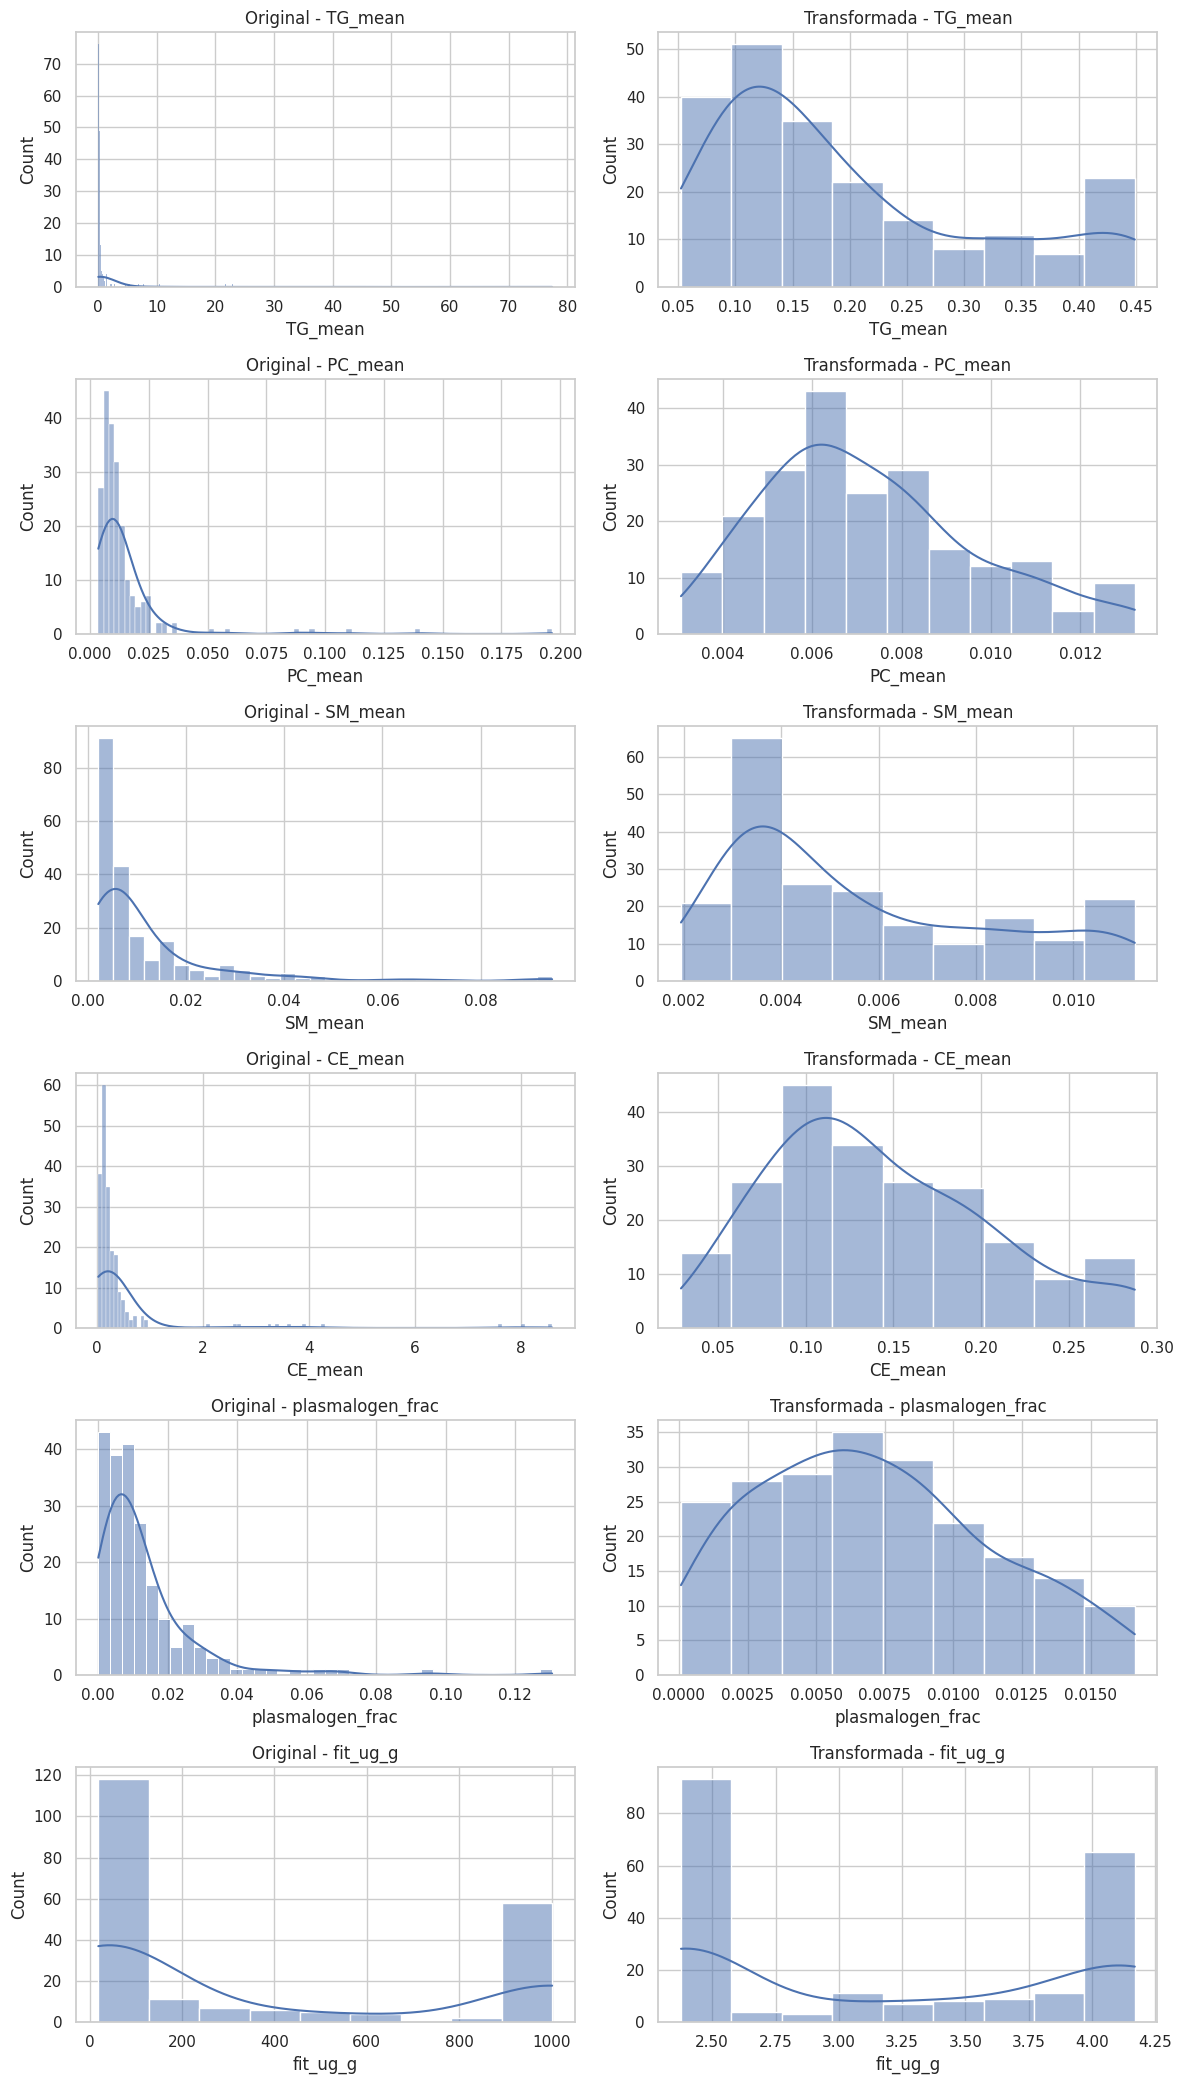

In [43]:
# Visualización de algunas variables relevantes antes y después
plot_candidates = [
    'TG_mean',
    'PC_mean',
    'SM_mean',
    'CE_mean',
    'plasmalogen_frac',
    'fit_ug_g'
]

selected_plot_cols = [c for c in plot_candidates if c in X_encoded.columns and c in X_transformed.columns]

if selected_plot_cols:
    fig, axes = plt.subplots(len(selected_plot_cols), 2, figsize=(12, 3.5 * len(selected_plot_cols)))

    if len(selected_plot_cols) == 1:
        axes = np.array([axes])

    for i, col in enumerate(selected_plot_cols):
        sns.histplot(X_encoded[col], kde=True, ax=axes[i, 0])
        axes[i, 0].set_title(f'Original - {col}')

        sns.histplot(X_transformed[col], kde=True, ax=axes[i, 1])
        axes[i, 1].set_title(f'Transformada - {col}')

    plt.tight_layout()
    plt.show()
else:
    print('No se encontraron variables candidatas para graficar.')

# 9. Escalamiento de variables

### Justificación

Las variables numéricas presentan diferentes órdenes de magnitud. Si no se escalan, variables con rangos grandes pueden dominar modelos sensibles a distancia o magnitud.

Se aplica **StandardScaler** sobre variables continuas transformadas para centrar cada variable en media 0 y desviación estándar 1. Esto ayuda a:

- garantizar impacto más equitativo de las variables;
- mejorar estabilidad numérica;
- acelerar convergencia de algoritmos como regresión logística;
- y preparar adecuadamente técnicas como PCA.

In [44]:
X_scaled = X_transformed.copy()

scaler = StandardScaler()
X_scaled[continuous_cols] = scaler.fit_transform(X_transformed[continuous_cols])

scaling_check = pd.DataFrame({
    'mean_after_scaling': X_scaled[continuous_cols].mean(),
    'std_after_scaling': X_scaled[continuous_cols].std()
}).round(3)

print('Verificación de escalamiento en variables continuas:')
display(scaling_check.head(15))

Verificación de escalamiento en variables continuas:


,mean_after_scaling,std_after_scaling
age,0.0,1.002
fit_ug_g,0.0,1.002
Cer(d18:1/16:0),-0.0,1.002
Cer(d18:1/20:0),0.0,1.002
Cer(d18:1/22:0),-0.0,1.002
Cer(d18:1/23:0),0.0,1.002
Cer(d18:1/24:0),0.0,1.002
Cer(d18:1/24:1)+Cer(d18:2/24:0),0.0,1.002
Cer(d18:1/18:0),-0.0,1.002
Cholesterol sulfate,-0.0,1.002


# 10. Discretización o binning

### Justificación

La discretización por cuantiles convierte variables continuas en intervalos con frecuencia similar. Esta técnica puede ayudar a capturar relaciones no lineales y reducir sensibilidad a valores extremos.

En esta libreta se aplica de manera controlada a variables clínicas y características derivadas seleccionadas, no a todos los lípidos, para evitar expansión excesiva del espacio de características.

In [45]:
binning_candidates = [
    'age',
    'fit_ug_g',
    'TG_mean',
    'SM_mean',
    'CE_mean',
    'plasmalogen_frac'
]

binning_cols = [c for c in binning_candidates if c in X_transformed.columns]

X_binned = X_scaled.copy()
bin_cols_created = []

if binning_cols:
    binner = KBinsDiscretizer(
        n_bins=4,
        encode='ordinal',
        strategy='quantile'
    )

    binned_values = binner.fit_transform(X_transformed[binning_cols])

    for i, col in enumerate(binning_cols):
        new_col = f'{col}_qbin'
        X_binned[new_col] = binned_values[:, i].astype(int)
        bin_cols_created.append(new_col)

print('Variables discretizadas:', binning_cols)
print('Columnas creadas:', bin_cols_created)
display(X_binned[bin_cols_created].head() if bin_cols_created else pd.DataFrame())

Variables discretizadas: ['age', 'fit_ug_g', 'TG_mean', 'SM_mean', 'CE_mean', 'plasmalogen_frac']
Columnas creadas: ['age_qbin', 'fit_ug_g_qbin', 'TG_mean_qbin', 'SM_mean_qbin', 'CE_mean_qbin', 'plasmalogen_frac_qbin']


,age_qbin,fit_ug_g_qbin,TG_mean_qbin,SM_mean_qbin,CE_mean_qbin,plasmalogen_frac_qbin
0,2,0,2,3,0,3
1,2,1,1,3,3,2
2,0,1,0,1,1,3
3,3,1,2,2,2,3
4,1,0,2,0,0,3


# 11. Selección de características por métodos de filtrado

Esta sección responde al criterio de **Selección / extracción**.

Se aplican filtros para reducir dimensionalidad, disminuir complejidad y facilitar interpretabilidad antes de la fase de modelado.

## 11.1 Umbral de varianza

### Justificación

Las variables con varianza casi nula aportan poca información discriminativa y pueden aumentar complejidad sin contribuir al modelo. Se aplica `VarianceThreshold` para remover características con variabilidad insuficiente.

In [46]:
X_selection_input = X_binned.copy()

variance_selector = VarianceThreshold(threshold=0.01)
X_var_array = variance_selector.fit_transform(X_selection_input)

selected_variance_features = X_selection_input.columns[
    variance_selector.get_support()
].tolist()

removed_low_variance = [
    c for c in X_selection_input.columns
    if c not in selected_variance_features
]

X_var = pd.DataFrame(
    X_var_array,
    columns=selected_variance_features,
    index=X_selection_input.index
)

print('Variables antes de umbral de varianza:', X_selection_input.shape[1])
print('Variables retenidas:', X_var.shape[1])
print('Variables removidas por baja varianza:', len(removed_low_variance))

Variables antes de umbral de varianza: 174
Variables retenidas: 174
Variables removidas por baja varianza: 0


## 11.2 Filtro de correlación

### Justificación

La lipidómica suele presentar alta correlación entre variables de la misma familia. Mantener variables casi duplicadas incrementa complejidad y puede dificultar la interpretación. Por ello, se remueven variables con correlación absoluta mayor a 0.95, conservando una representación menos redundante.

In [47]:
corr_threshold = 0.95

corr_matrix = X_var.corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop_corr = [
    column for column in upper.columns
    if any(upper[column] > corr_threshold)
]

X_corr = X_var.drop(columns=to_drop_corr)

print('Variables antes del filtro de correlación:', X_var.shape[1])
print('Variables removidas por alta correlación:', len(to_drop_corr))
print('Variables retenidas después de correlación:', X_corr.shape[1])

Variables antes del filtro de correlación: 174
Variables removidas por alta correlación: 22
Variables retenidas después de correlación: 152


## 11.3 Selección supervisada con Mutual Information

### Justificación

Mutual Information permite detectar relaciones potencialmente no lineales entre cada predictor y la variable objetivo multiclase. Esto es adecuado para datos biomédicos, donde las relaciones entre biomarcadores y grupos clínicos pueden no ser lineales.

El objetivo es identificar características con mayor capacidad discriminativa para clasificar `CTRL`, `AA` y `CRC`.

In [48]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Máscara de variables discretas: dummies y bins
discrete_cols = [c for c in X_corr.columns if c in dummy_cols or c in bin_cols_created]
discrete_mask = [c in discrete_cols for c in X_corr.columns]

mi_scores = mutual_info_classif(
    X_corr,
    y_encoded,
    discrete_features=discrete_mask,
    random_state=RANDOM_STATE
)

mi_results = pd.DataFrame({
    'feature': X_corr.columns,
    'mutual_information': mi_scores,
    'is_discrete': discrete_mask
}).sort_values('mutual_information', ascending=False).reset_index(drop=True)

display(mi_results.head(30))

TOP_K = min(30, X_corr.shape[1])
top_mi_features = mi_results.head(TOP_K)['feature'].tolist()

print(f'Top {TOP_K} variables seleccionadas por Mutual Information.')

,feature,mutual_information,is_discrete
0,GlcCer(d18:1/24:0),0.381503,False
1,PE(P-18:0/18:1),0.359906,False
2,TG(51:4),0.353423,False
3,TG(53:0),0.353109,False
4,SM(d18:0/18:0),0.339773,False
5,PC(36:5),0.333807,False
6,Cer(d18:1/24:0),0.318235,False
7,PC(O-16:0/16:0),0.317422,False
8,PC(O-16:0/22:4),0.317257,False
9,SM(42:3),0.312242,False


Top 30 variables seleccionadas por Mutual Information.


## 11.4 Selección supervisada con ANOVA

### Justificación

ANOVA F-score evalúa si la media de una característica difiere entre grupos clínicos. Se usa como filtro complementario a Mutual Information, ya que ANOVA captura diferencias lineales o globales entre clases, mientras que Mutual Information puede capturar relaciones no lineales.

In [49]:
anova_scores, anova_pvalues = f_classif(X_corr, y_encoded)

anova_results = pd.DataFrame({
    'feature': X_corr.columns,
    'anova_score': anova_scores,
    'p_value': anova_pvalues
}).sort_values('anova_score', ascending=False).reset_index(drop=True)

display(anova_results.head(30))

,feature,anova_score,p_value
0,fit_ug_g,57.173482,1.632804e-20
1,fob_YES,40.027397,1.964154e-15
2,fit_ug_g_qbin,38.318714,6.795451e-15
3,CE(20:4),34.512100,1.139581e-13
4,SM(33:1),19.514428,1.709336e-08
5,CE(20:5),19.423551,1.845320e-08
6,SM(d18:1/24:1) + SM(d18:2/24:0),18.311145,4.731513e-08
7,CE(18:2),17.719369,7.835366e-08
8,PC(O-16:0/18:2),15.744242,4.295215e-07
9,PC(O-16:0/16:0),15.703925,4.448305e-07


## 11.5 Chi-cuadrado para variables categóricas/discretizadas

### Justificación

Chi-cuadrado es apropiado para evaluar asociación entre variables categóricas o discretizadas y la variable objetivo. Por ello se aplica únicamente a dummies y variables discretizadas, no a biomarcadores continuos escalados.

In [50]:
chi2_features = [c for c in discrete_cols if c in X_corr.columns]

if chi2_features:
    chi2_scores, chi2_pvalues = chi2(X_corr[chi2_features].clip(lower=0), y_encoded)

    chi2_results = pd.DataFrame({
        'feature': chi2_features,
        'chi2_score': chi2_scores,
        'p_value': chi2_pvalues
    }).sort_values('chi2_score', ascending=False).reset_index(drop=True)

    display(chi2_results)
else:
    chi2_results = pd.DataFrame()
    print('No hay variables categóricas/discretizadas disponibles para Chi-cuadrado.')

,feature,chi2_score,p_value
0,fit_ug_g_qbin,28.270807,7.262267e-07
1,fob_YES,23.900704,6.456960e-06
2,SM_mean_qbin,9.567609,8.364119e-03
3,TG_mean_qbin,4.041178,1.325773e-01
4,CE_mean_qbin,3.325374,1.896287e-01
5,plasmalogen_frac_qbin,3.271654,1.947912e-01
6,gender_Male,2.848660,2.406697e-01


# 12. Extracción de características mediante PCA

### Justificación

PCA se utiliza como técnica de extracción no supervisada para generar una representación compacta del conjunto de variables numéricas. A diferencia de PLS-DA, PCA no utiliza las etiquetas del target para construir los componentes, por lo que es adecuado como exploración estructural y reducción de dimensionalidad.

Se retienen componentes suficientes para explicar al menos 90% de la varianza.

In [51]:
# PCA sobre variables continuas retenidas después del filtro de correlación
continuous_corr_cols = [
    c for c in X_corr.columns
    if c in continuous_cols or c in family_features or c in subfamily_features or c in ratio_features or c in structural_features
]

continuous_corr_cols = [c for c in continuous_corr_cols if c in X_corr.columns]

pca = PCA(n_components=0.90, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_corr[continuous_corr_cols])

print('Variables continuas usadas en PCA:', len(continuous_corr_cols))
print('Número de componentes retenidos:', pca.n_components_)
print('Varianza explicada acumulada:', round(pca.explained_variance_ratio_.sum(), 4))

Variables continuas usadas en PCA: 145
Número de componentes retenidos: 36
Varianza explicada acumulada: 0.9022


,component,explained_variance_ratio,cumulative_variance
0,PC1,0.242133,0.242133
1,PC2,0.167157,0.409290
2,PC3,0.069327,0.478617
3,PC4,0.052487,0.531103
4,PC5,0.041610,0.572713
5,PC6,0.034589,0.607302
6,PC7,0.028200,0.635502
7,PC8,0.022816,0.658318
8,PC9,0.019701,0.678019
9,PC10,0.016717,0.694736


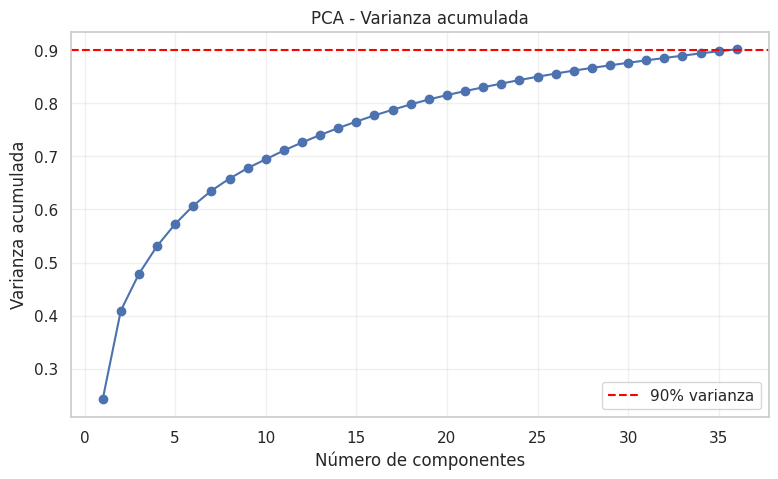

In [52]:
pca_variance = pd.DataFrame({
    'component': [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'explained_variance_ratio': pca.explained_variance_ratio_,
    'cumulative_variance': np.cumsum(pca.explained_variance_ratio_)
})

display(pca_variance.head(15))

plt.figure(figsize=(9,5))
plt.plot(
    range(1, len(pca_variance)+1),
    pca_variance['cumulative_variance'],
    marker='o'
)
plt.axhline(0.90, linestyle='--', color='red', label='90% varianza')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.title('PCA - Varianza acumulada')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

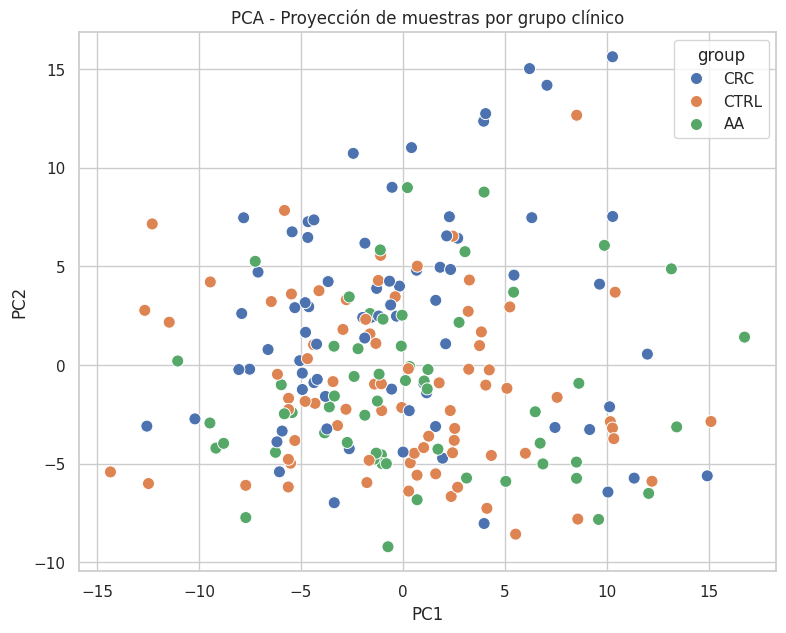

In [53]:
if X_pca.shape[1] >= 2:
    pca_df = pd.DataFrame({
        'PC1': X_pca[:, 0],
        'PC2': X_pca[:, 1],
        'group': y.values
    })

    plt.figure(figsize=(9,7))
    sns.scatterplot(
        data=pca_df,
        x='PC1',
        y='PC2',
        hue='group',
        s=75
    )
    plt.title('PCA - Proyección de muestras por grupo clínico')
    plt.show()

# 13. Evaluación complementaria de importancia con Random Forest

### Justificación

Aunque el modelado formal corresponde a una fase posterior, Random Forest se utiliza aquí como apoyo exploratorio para contrastar si las variables seleccionadas por métodos de filtrado también aparecen como relevantes dentro de un modelo no lineal.

Esto facilita la interpretación preliminar de biomarcadores candidatos.

,feature,rf_importance
0,fit_ug_g,0.037431
1,TG(51:4),0.037327
2,CE(20:5),0.035374
3,SM(d18:0/18:0),0.035054
4,PC(36:5),0.029540
5,PC(O-16:0/16:0),0.025732
6,SM(42:3),0.023602
7,SM(33:1),0.022170
8,GlcCer(d18:1/24:0),0.021262
9,PE(P-18:0/18:1),0.021102


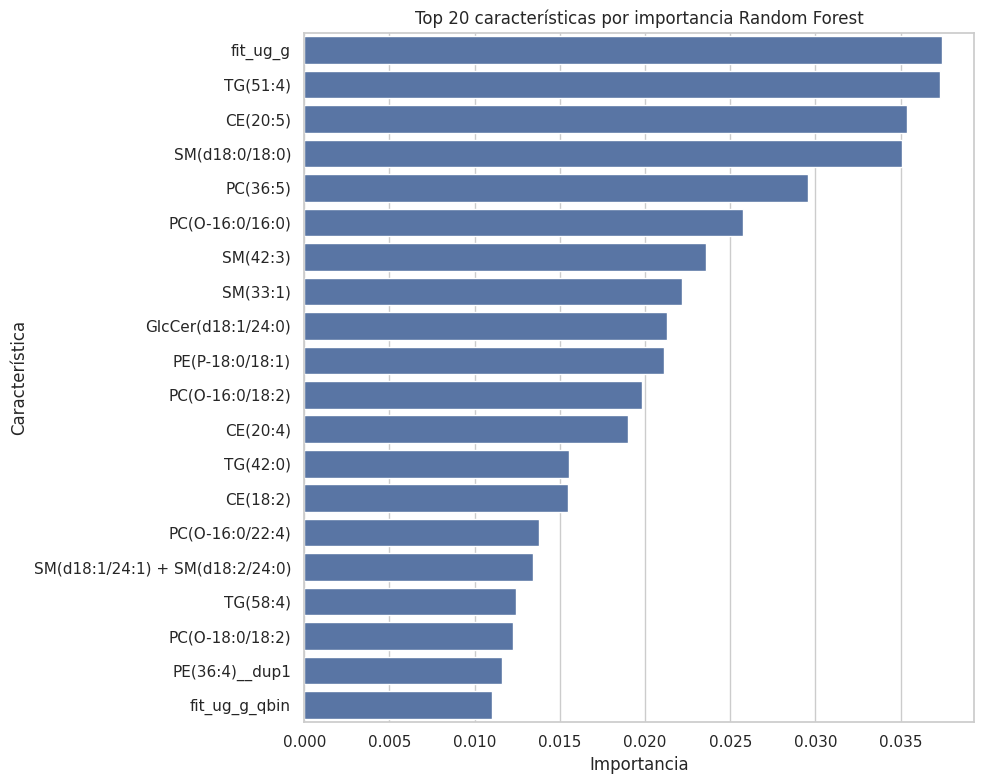

In [54]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

rf.fit(X_corr, y_encoded)

rf_importance = pd.DataFrame({
    'feature': X_corr.columns,
    'rf_importance': rf.feature_importances_
}).sort_values('rf_importance', ascending=False).reset_index(drop=True)

display(rf_importance.head(30))

plt.figure(figsize=(10,8))
sns.barplot(
    data=rf_importance.head(20),
    x='rf_importance',
    y='feature'
)
plt.title('Top 20 características por importancia Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

# 14. Matrices finales sugeridas para modelado

### Justificación

Al cierre del Avance 2 se dejan tres representaciones candidatas:

1. `X_corr`: matriz depurada, transformada, escalada, codificada y filtrada por varianza/correlación.
2. `X_top_mi`: subconjunto de variables con mayor información mutua.
3. `X_pca_df`: representación compacta mediante PCA.

Estas matrices reducen complejidad, aceleran entrenamiento y permiten comparar interpretabilidad frente a compacidad.

In [55]:
X_top_mi = X_corr[top_mi_features].copy()

X_pca_df = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(X_pca.shape[1])],
    index=X_corr.index
)

print('Matriz depurada X_corr:', X_corr.shape)
print('Matriz Top MI X_top_mi:', X_top_mi.shape)
print('Matriz PCA X_pca_df:', X_pca_df.shape)
print('Target y:', y.shape)

# Guardar archivos opcionales para etapas posteriores
X_corr.to_csv('avance2_X_corr.csv', index=False)
X_top_mi.to_csv('avance2_X_top_mi.csv', index=False)
X_pca_df.to_csv('avance2_X_pca.csv', index=False)
pd.Series(y, name='group').to_csv('avance2_y.csv', index=False)

print('Archivos CSV generados para uso posterior.')

Matriz depurada X_corr: (211, 152)
Matriz Top MI X_top_mi: (211, 30)
Matriz PCA X_pca_df: (211, 36)
Target y: (211,)
Archivos CSV generados para uso posterior.


# 15. Verificación contra rúbrica

| Criterio | Evidencia en la libreta |
|---|---|
| Construcción de nuevas características | Secciones 6.1, 6.2, 6.3 y 6.4: agregados por familia, subfamilia, ratios metabólicos y características estructurales. |
| Conocimiento del dominio | Las variables nuevas se basan en familias lipidómicas, balances metabólicos, insaturación, longitud de cadena y plasmalógenos. |
| Codificación categórica | Sección 7: One-Hot Encoding para variables nominales. |
| Transformación | Sección 8: Box-Cox para lípidos positivos y Yeo-Johnson para clínicas/derivadas. |
| Escalamiento | Sección 9: StandardScaler para impacto equitativo y convergencia. |
| Discretización | Sección 10: Binning por cuantiles para variables seleccionadas. |
| Selección | Sección 11: Umbral de varianza, correlación, Mutual Information, ANOVA y Chi-cuadrado. |
| Extracción | Sección 12: PCA con 90% de varianza acumulada. |
| Interpretabilidad | Secciones 11 y 13: rankings de variables y Random Forest importance. |
| Conclusión CRISP-ML(Q) | Sección 16. |

# 16. Conclusiones de la fase de Preparación de Datos en CRISP-ML(Q)

Durante esta fase de **Preparación de Datos** dentro del marco CRISP-ML(Q), el conjunto original de datos lipidómicos y metabolómicos fue transformado en una matriz de características más adecuada para aprendizaje automático supervisado.

Primero, se mantuvo la continuidad con el Avance 1 mediante la reconstrucción de encabezados, la eliminación de variables identificadoras, la depuración de variables redundantes y el tratamiento controlado de valores faltantes. Posteriormente, se construyeron nuevas características basadas en conocimiento del dominio, incluyendo agregados por familias lipidómicas, subfamilias, ratios metabólicos y atributos estructurales como longitud media de cadena, insaturación media y fracción de plasmalógenos.

Estas nuevas variables permiten representar patrones metabólicos globales y facilitan la interpretación biomédica del modelo. La codificación de variables categóricas mediante One-Hot Encoding evitó introducir jerarquías artificiales, mientras que las transformaciones Box-Cox y Yeo-Johnson ayudaron a reducir asimetría en las variables numéricas. El escalamiento mediante StandardScaler permitió que las características tuvieran una escala comparable, mitigando el riesgo de sesgo por magnitud y favoreciendo la convergencia de algoritmos sensibles a escala.

Finalmente, se aplicaron métodos de filtrado y extracción de características, incluyendo umbral de varianza, filtro de correlación, Mutual Information, ANOVA, Chi-cuadrado y PCA. Estas técnicas reducen dimensionalidad, disminuyen redundancia, aceleran el entrenamiento y generan una base más interpretable para la siguiente fase de modelado supervisado.

Como resultado, el dataset queda preparado para entrenar modelos de clasificación multiclase orientados a discriminar entre `CTRL`, `AA` y `CRC`, preservando tanto la utilidad predictiva como la interpretabilidad biomédica.

# 17. Referencias

Albóniga, O. E., Cubiella, J., Bujanda, L., Aspichueta, P., Blanco, M. E., Lanza, B., Alonso, C., & Falcón-Pérez, J. M. (2025). *Metabolic signature in combination with fecal immunochemical test as a non-invasive tool for advanced colorectal neoplasia diagnosis*. **Cancers, 17**(14), 2339. https://doi.org/10.3390/cancers17142339

Galli, S. (2022). *Python Feature Engineering Cookbook* (2nd ed.). Packt Publishing.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

Visengeriyeva, L., Kammer, A., Bär, I., Kniesz, A., & Plöd, M. (2023). *CRISP-ML(Q): The ML lifecycle process*. MLOps. INNOQ. https://ml-ops.org/content/crisp-ml